In [95]:
library(Seurat)
library(SCopeLoomR)
library(tidyverse)
library(SeuratDisk)
library(RColorBrewer)

In [34]:
options(repr.plot.width = 12, repr.plot.height = 8, repr.plot.res = 200)

# Load Fibroblast Data

In [ ]:
data <- LoadH5Seurat(
    file = "./TERVA2.h5Seurat"
)

In [4]:
data

An object of class Seurat 
32420 features across 8581 samples within 2 assays 
Active assay: RNA (32283 features, 2000 variable features)
 3 layers present: counts, data, scale.data
 1 other assay present: ADT
 4 dimensional reductions calculated: apca, harmony, pca, umap

In [5]:
unique(data$celltype)

[1] Cd248+ Pi16+ Fibroblasts          Mfap4+ Fibroblasts               
[3] Ccl11+ Fibroblasts                Mgp+ Aebp1+ Activated fibroblasts
[5] Il1b+ Fibroblasts                
32 Levels: B cells Folr2+ Lyve1+ M2 Macrophages ... MAST cells

In [6]:
# relevel "celltype" column
data$celltype <- droplevels(data$celltype)

In [7]:
unique(data$celltype)

[1] Cd248+ Pi16+ Fibroblasts          Mfap4+ Fibroblasts               
[3] Ccl11+ Fibroblasts                Mgp+ Aebp1+ Activated fibroblasts
[5] Il1b+ Fibroblasts                
5 Levels: Ccl11+ Fibroblasts Cd248+ Pi16+ Fibroblasts ... Il1b+ Fibroblasts

* Total of 5 fibroblast subclusters.

# Distribution of Fibroblast Subclusters

In [66]:
meta_data <- data@meta.data |> 
    select(c("tissue_id", "celltype", "celltype.group", "group_id"))

In [67]:
table(meta_data$celltype)


               Ccl11+ Fibroblasts          Cd248+ Pi16+ Fibroblasts 
                             2781                              2250 
               Mfap4+ Fibroblasts Mgp+ Aebp1+ Activated fibroblasts 
                             1756                              1600 
                Il1b+ Fibroblasts 
                              194 

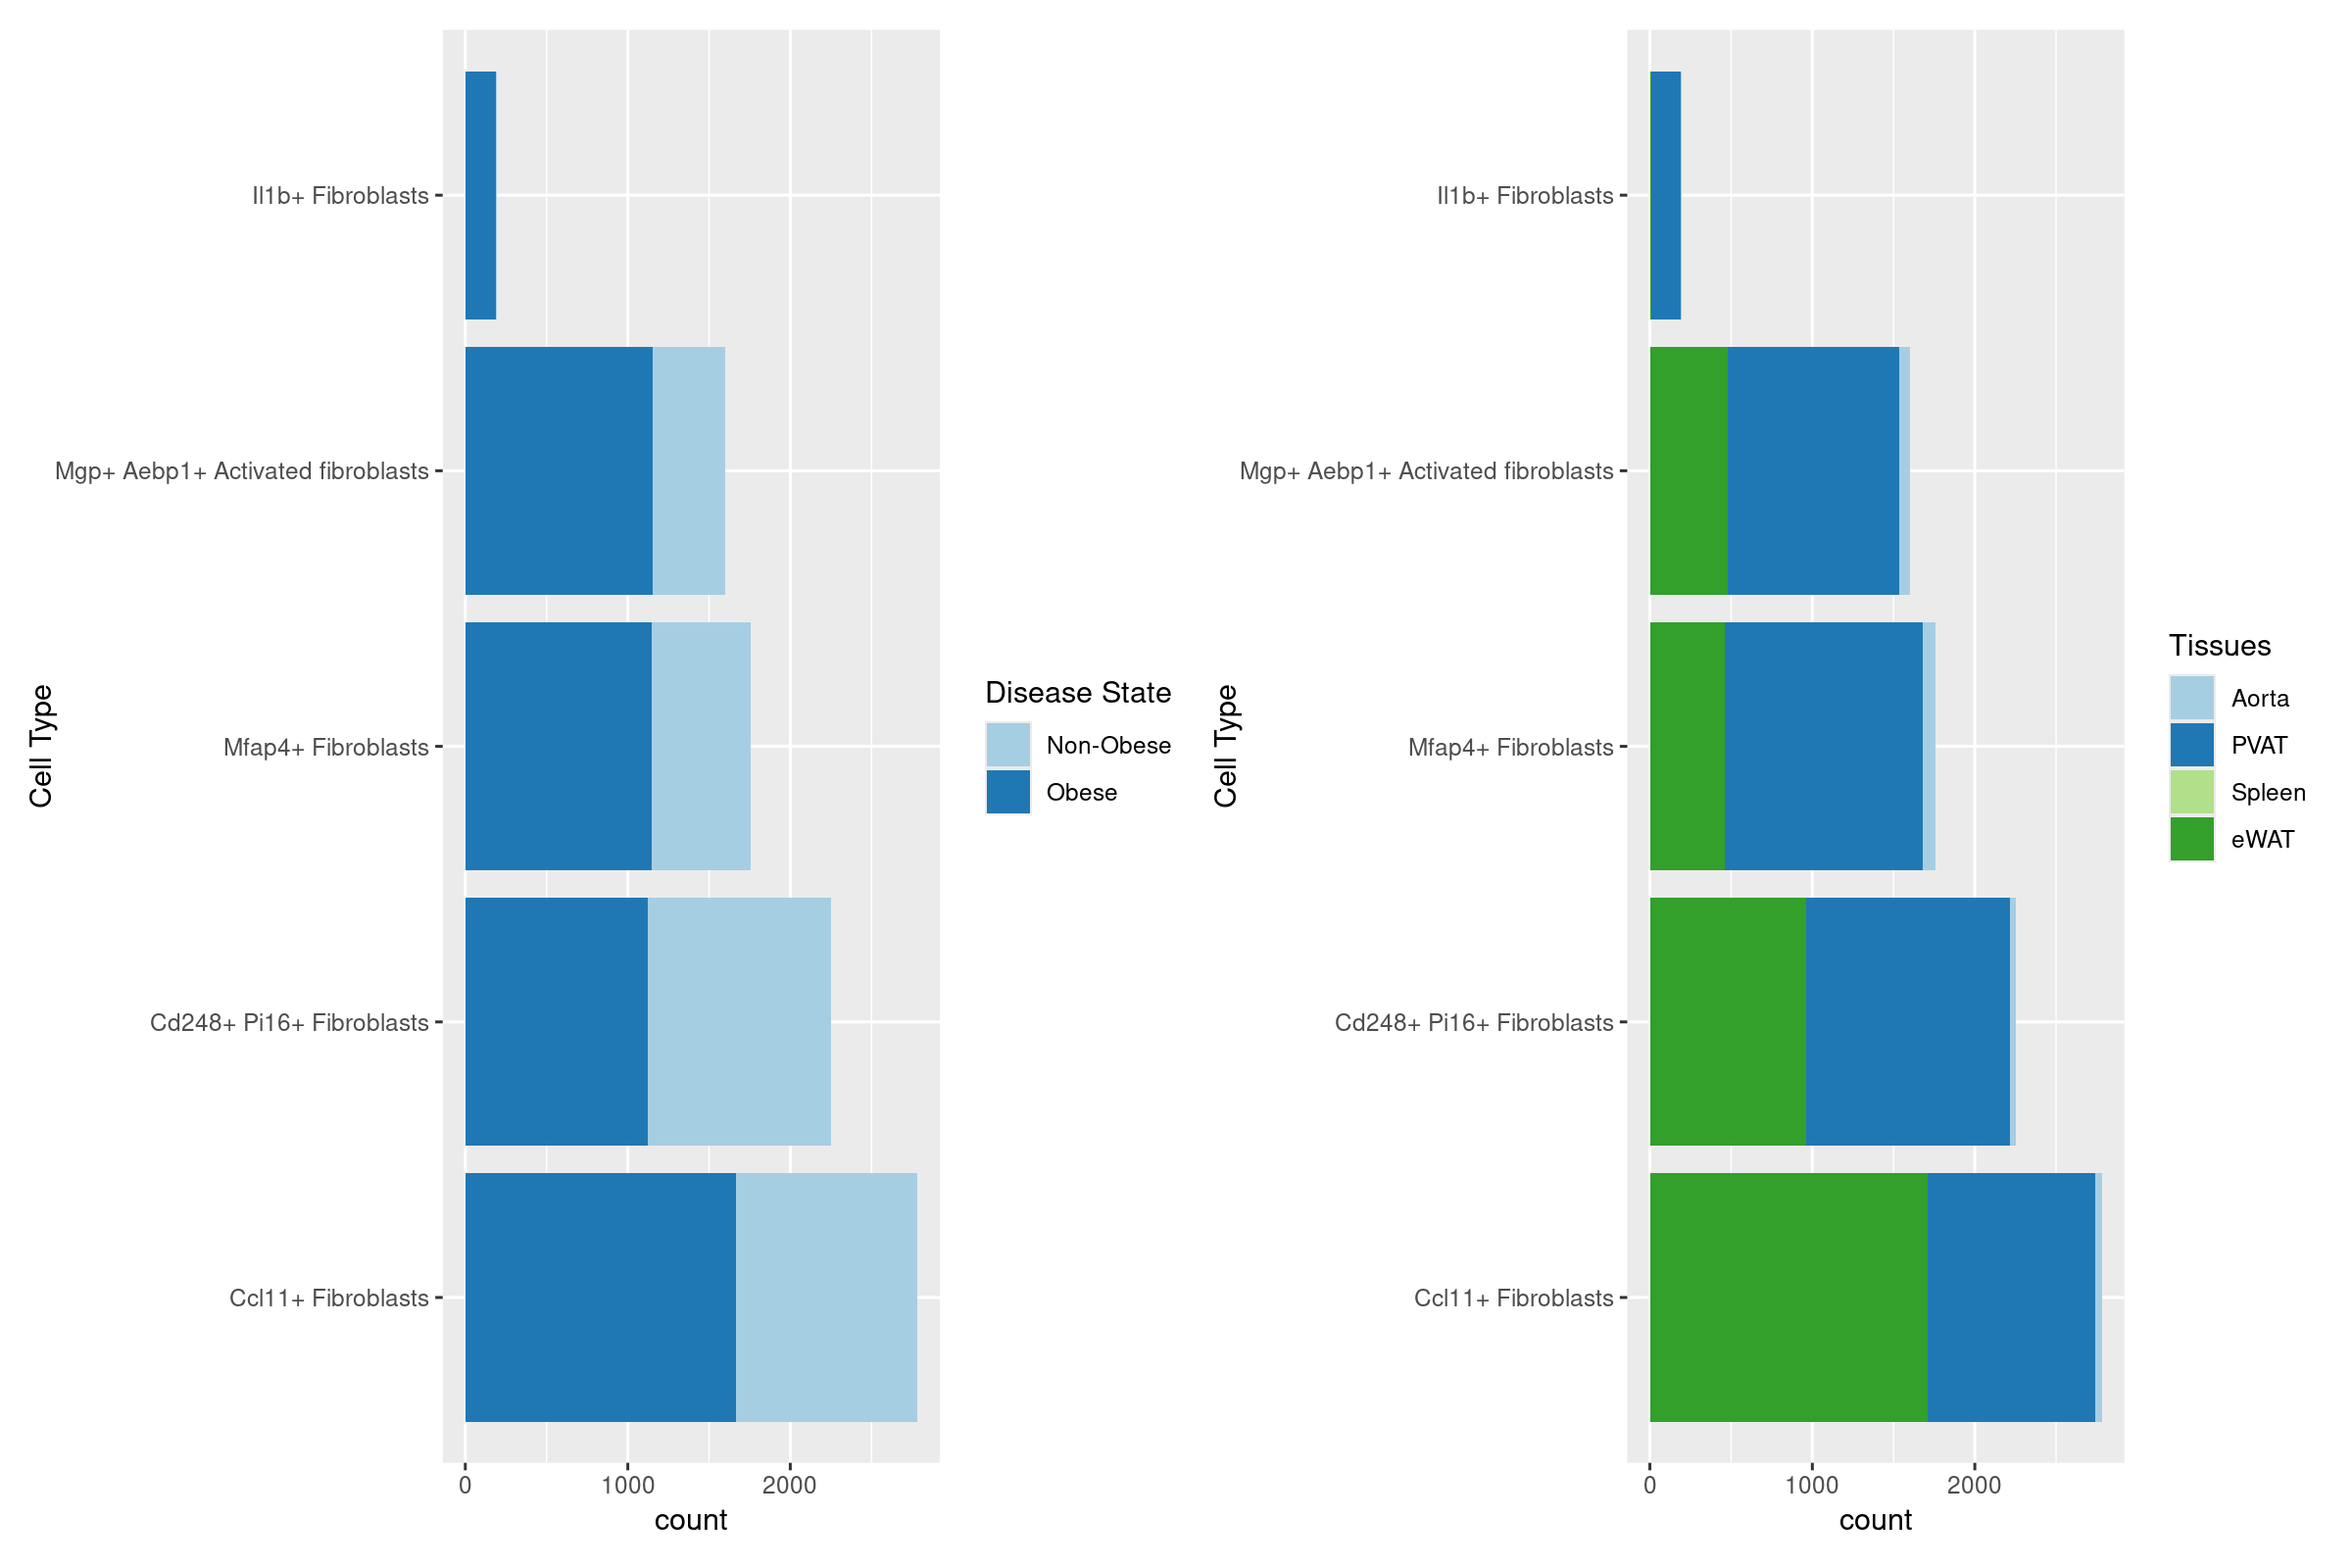

In [100]:
ggplot(data = meta_data, aes(x = celltype, fill = group_id)) +
    geom_bar() +
    xlab("Cell Type") +
    labs(fill = "Disease State") +
    coord_flip() +
    scale_fill_manual(values = brewer.pal(3, "Paired")) +
    ggplot(data = meta_data, aes(x = celltype, fill = tissue_id)) + 
    geom_bar() +
    xlab("Cell Type") +
    labs(fill = "Tissues") +
    coord_flip() +
    scale_fill_manual(values = brewer.pal(4, "Paired"))

* Il1b+ subcluster has the least amount of fibroblasts (194 cells) and is only found in PVAT.
* Ccl11+ subcluster has the highest number of fibroblasts.
* Except Cd248+ Pi16+ fibroblasts, all fibroblast subclusters are more dominant in obese mice.
* Fibroblasts mostly come from eWAT and PVAT.
* Only Ccl11+ fibroblasts mostly come from eWAT. Other populations are more common in PVAT.

# Create a .loom File

In [57]:
build_loom(
    file.name = "TERVA.loom",
    dgem = data@assays$RNA@counts, # add raw counts
    title = "Fibroblasts",
    default.embedding = data@reductions$umap@cell.embeddings, # add umap embeddings to visualize loom file using SCope
    default.embedding.name = "umap"
)

[1] "Adding global attributes..."
[1] "Adding matrix..."
  |======================================================================| 100%[1] "Adding column attributes..."


Warning message in doTryCatch(return(expr), name, parentenv, handler):
“Default metric nUMI was not added because the input matrix does not seem to be the raw counts.”


[1] "Adding default metrics nGene..."
[1] "Adding default embedding..."
[1] "Adding row attributes..."
[1] "Adding columns graphs..."
[1] "Adding row graphs..."
[1] "Adding layers..."


# Save meta.data for Future Use

In [64]:
write.csv(meta_data, "meta_data.csv")